In [1]:
print("all ok")

all ok


In [2]:
import sys, os

# Get project root — one level up from 'research_and_analyst'
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

print("Project root added to path:", project_root)

Project root added to path: d:\ARTIFICIAL INTELLIGENCE\Multi-Agent System for Research Analysis and Generation Automation\automated-research-synthesis


In [3]:
from research_and_analyst.utils.model_loader import ModelLoader

In [4]:
model_loader = ModelLoader()

{"timestamp": "2026-08-19T07:42:30.614334Z", "level": "info", "event": "Initializing ApiKeyManager"}
{"timestamp": "2026-08-19T07:42:30.615362Z", "level": "info", "event": "ANTHROPIC_API_KEY loaded successfully from environment"}
{"timestamp": "2026-08-19T07:42:30.616162Z", "level": "info", "event": "OPENAI_API_KEY loaded successfully from environment"}
{"timestamp": "2026-08-19T07:42:30.616760Z", "level": "info", "event": "GOOGLE_API_KEY loaded successfully from environment"}
{"timestamp": "2026-08-19T07:42:30.617515Z", "level": "info", "event": "GROQ_API_KEY loaded successfully from environment"}
{"path": "D:\\ARTIFICIAL INTELLIGENCE\\Multi-Agent System for Research Analysis and Generation Automation\\automated-research-synthesis\\research_and_analyst\\config\\configuration.yaml", "keys": ["astra_db", "embedding_model", "retriever", "llm"], "timestamp": "2026-08-19T07:42:30.620029Z", "level": "info", "event": "Configuration loaded successfully"}
{"config_keys": ["astra_db", "embeddin

In [5]:
llm=model_loader.load_llm()

{"provider": "anthropic", "model": "claude-sonnet-4-5-20250929", "timestamp": "2026-08-19T07:42:30.626066Z", "level": "info", "event": "Loading LLM"}
{"provider": "anthropic", "model": "claude-sonnet-4-5-20250929", "timestamp": "2026-08-19T07:42:30.627042Z", "level": "info", "event": "LLM loaded successfully"}


In [6]:
llm.invoke("hi").content

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


'Hello! How can I help you today?'

In [7]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

In [8]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage,HumanMessage , SystemMessage
from langgraph.checkpoint.memory import MemorySaver

In [9]:
class Analyst(BaseModel):
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    affiliation: str = Field(description="Primary affiliation of the analyst.")
    description: str = Field(description="Description of the analyst focus, concerns, and motives.")
    
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

In [10]:
Analyst(
    name="Nikhil Srivastava",
    role="Agentic AI eng",
    affiliation="AI Research LAB",
    description="I am genai developer as well as mentor"
    )

Analyst(name='Nikhil Srivastava', role='Agentic AI eng', affiliation='AI Research LAB', description='I am genai developer as well as mentor')

In [11]:
analyst = Analyst(
    name="Nikhil Srivastava",
    role="Agentic AI eng",
    affiliation="AI Research LAB",
    description="I am genai developer as well as mentor"
    )

In [12]:
analyst.name

'Nikhil Srivastava'

In [13]:
analyst.role

'Agentic AI eng'

In [14]:
analyst.affiliation

'AI Research LAB'

In [15]:
print(analyst.persona)

Name: Nikhil Srivastava
Role: Agentic AI eng
Affiliation: AI Research LAB
Description: I am genai developer as well as mentor



In [16]:
class Perspectives(BaseModel):
       analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

In [17]:
class GenerateAnalystsState(TypedDict):
    topic: str #research topic
    max_analysts: int # number of analyst
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

In [18]:
GenerateAnalystsState(
    topic = "finance",
    max_analysts= 5,
    human_analyst_feedback= "give the real info",  
)

{'topic': 'finance',
 'max_analysts': 5,
 'human_analyst_feedback': 'give the real info'}

In [19]:
Analyst(
        name="Dr. Neha Patel",
        role="Medical Data Scientist",
        affiliation="Stanford Medicine",
        description="Focuses on predictive models for patient outcomes."
    ),

(Analyst(name='Dr. Neha Patel', role='Medical Data Scientist', affiliation='Stanford Medicine', description='Focuses on predictive models for patient outcomes.'),)

In [20]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [21]:
print([analyst_instructions.format(
        topic="education",
        max_analysts=4,
        human_analyst_feedback="please exaplain only on AI"
        
        )] + ["Generate the set of analysts."])

['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease exaplain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']


In [22]:
def create_analyst(state:GenerateAnalystsState):
    """
    it is creating my analyst
    
    """
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback","")
    
    structured_llm = llm.with_structured_output(Perspectives)
    
    system_messages = analyst_instructions.format(
        topic=topic,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback
        
        )
    analysts = structured_llm.invoke([SystemMessage(content=system_messages)]+ [HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

In [23]:
create_analyst(
    {'topic': 'health',
    'max_analysts': 2,
    'human_analyst_feedback': 'give the real info'}
    )

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Sarah Chen', role='Public Health Equity Researcher', affiliation='Johns Hopkins Bloomberg School of Public Health', description='Dr. Chen specializes in health disparities and social determinants of health. Her primary focus is on understanding how socioeconomic factors, race, geography, and access to care create inequities in health outcomes. She is deeply concerned with vulnerable populations including low-income communities, racial minorities, and rural residents who face systemic barriers to healthcare. Her research examines policy interventions that can reduce these gaps, including Medicaid expansion, community health worker programs, and culturally competent care models. She is motivated by a commitment to health justice and believes that healthcare is a fundamental human right that should be accessible to all regardless of ability to pay or zip code.'),
  Analyst(name='Dr. Michael Torres', role='Digital Health Innovation Specialist', affiliation='

In [24]:
def human_feedback(state):
    """ No-op node that should be interrupted on """
    pass

In [25]:
def should_continue(state):
    feedback = (state.get("human_analyst_feedback") or "").strip().lower()
    if feedback and feedback not in ["", "none", "skip", "done", "continue"]:
        return "create_analyst"
    return END

In [26]:
from IPython.display import Image, display

# First Workflow

In [27]:
builder = StateGraph(GenerateAnalystsState)

In [28]:
builder.add_node("create_analyst",create_analyst)
builder.add_node("human_feedback", human_feedback)

In [29]:
builder.add_edge(START,"create_analyst")
builder.add_edge("create_analyst", "human_feedback")
builder.add_conditional_edges("human_feedback",
                        should_continue,
                        ["create_analyst",
                        END])

In [30]:
memory = MemorySaver()

In [31]:
graph = builder.compile(interrupt_before= ["human_feedback"],checkpointer= memory)

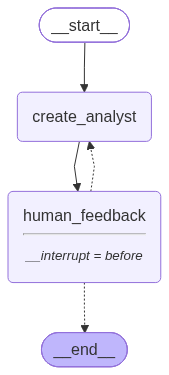

In [32]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [33]:
topic = "the benefits of adopting Langgraph as an agent framework"

In [34]:
max_analysts = 4

In [35]:
thread =  {"configurable":{"thread_id":1}}

In [ ]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

In [ ]:
state = graph.get_state(thread)

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Analyst')]


In [ ]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'analysts': [Analyst(name='Dr. Sarah Chen', role='AI Architecture Specialist', affiliation='Enterprise AI Solutions Lab', description="Dr. Chen focuses on the technical architecture and design patterns enabled by Langgraph. She is particularly interested in how Langgraph's graph-based approach to agent orchestration compares to traditional sequential frameworks, examining state management, control flow flexibility, and the ability to build complex multi-agent systems. Her primary concern is understanding how Langgraph's architecture enables more maintainable and scalable agent applications."), Analyst(name='Marcus Rodriguez', role='Developer Experience Researcher', affiliation='DevTools Innovation Institute', description='Marcus specializes in developer productivity and the practical aspects of adopting new frameworks. He evaluates Langgraph from the perspective of ease of use,

In [ ]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'analysts': [Analyst(name='Dr. Sarah Chen', role='AI Architecture Specialist', affiliation='Enterprise AI Solutions Lab', description="Dr. Chen focuses on the technical architecture and design patterns enabled by Langgraph. She is particularly interested in how Langgraph's graph-based approach to agent orchestration compares to traditional sequential frameworks, examining state management, control flow flexibility, and the ability to build complex multi-agent systems. Her primary concern is understanding how Langgraph's architecture enables more maintainable and scalable agent applications."),
  Analyst(name='Marcus Rodriguez', role='Developer Experience Researcher', affiliation='DevTools Innovation Institute', description='Marcus specializes in developer productivity and the practical aspects of adopting new frameworks. He evaluates Langgraph from the perspective of ease of use, learning curve, 

In [ ]:
state.next

('human_feedback',)

In [ ]:
memory.storage.items()

dict_items([('1', defaultdict(<class 'dict'>, {'': {'1f19ba10-1495-6a78-bfff-919af6f43fe0': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-08-19T07:38:43.882020+00:00\xa2id\xd9$1f19ba10-1495-6a78-bfff-919af6f43fe0\xb0channel_versions\x81\xa9__start__\xd9300000000000000000000000000000001.0.8313864372462237\xadversions_seen\x81\xa9__input__\x80\xb0updated_channels\x91\xa9__start__'), ('msgpack', b'\x83\xa6source\xa5input\xa4step\xff\xa7parents\x80'), None), '1f19ba10-149d-6f3b-8000-2f8f37529a4a': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-08-19T07:38:43.885402+00:00\xa2id\xd9$1f19ba10-149d-6f3b-8000-2f8f37529a4a\xb0channel_versions\x84\xa9__start__\xd9400000000000000000000000000000002.0.36292970175396266\xa5topic\xd9400000000000000000000000000000002.0.36292970175396266\xacmax_analysts\xd9400000000000000000000000000000002.0.36292970175396266\xb8branch:to:create_analyst\xd9400000000000000000000000000000002.0.36292970175396266\xadversions_seen\x82\xa9__input__\x80\xa9__start__\x81\xa9__start_

In [ ]:
state.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19ba10-8b50-6e07-8001-a66c989f5230'}}

In [ ]:
graph.update_state(thread,
                   {"human_analyst_feedback":"add something from the startup perspective and focus on the latest enterprise application"},as_node="human_feedback"
                   )

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19ba10-8cc6-610f-8002-d8906e6e0695'}}

In [ ]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Sarah Chen
Affiliation: Enterprise AI Solutions Lab
Role: AI Architecture Specialist
Description: Dr. Chen focuses on the technical architecture and design patterns enabled by Langgraph. She is particularly interested in how Langgraph's graph-based approach to agent orchestration compares to traditional sequential frameworks, examining state management, control flow flexibility, and the ability to build complex multi-agent systems. Her primary concern is understanding how Langgraph's architecture enables more maintainable and scalable agent applications.
--------------------------------------------------
Name: Marcus Rodriguez
Affiliation: DevTools Innovation Institute
Role: Developer Experience Researcher
Description: Marcus specializes in developer productivity and the practical aspects of adopting new frameworks. He evaluates Langgraph from the perspective of ease of use, learning curve, debugging capabilities, and integration with existing development workflows. His motiv

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Name: Dr. Sarah Chen
Affiliation: Fortune 500 Technology Consulting Firm
Role: Enterprise Architecture Strategist
Description: Dr. Chen specializes in evaluating enterprise-grade AI frameworks for large-scale deployments. She focuses on how Langgraph enables robust, production-ready agent systems with emphasis on scalability, reliability, and integration with existing enterprise infrastructure. Her primary concerns include governance, observability, debugging capabilities, and how Langgraph's state management and persistence features support mission-critical applications in regulated industries.
--------------------------------------------------
Name: Marcus Rodriguez
Affiliation: AI-Native Startup Ecosystem
Role: Startup CTO & Technical Co-founder
Description: Marcus represents the fast-moving startup perspective, focusing on rapid prototyping, time-to-market, and developer velocity. He evaluates Langgraph through the lens of resource-constrained teams building innovative AI products.

In [ ]:
state = graph.get_state(thread)

In [ ]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application', 'analysts': [Analyst(name='Dr. Sarah Chen', role='Enterprise Architecture Strategist', affiliation='Fortune 500 Technology Consulting Firm', description="Dr. Chen specializes in evaluating enterprise-grade AI frameworks for large-scale deployments. She focuses on how Langgraph enables robust, production-ready agent systems with emphasis on scalability, reliability, and integration with existing enterprise infrastructure. Her primary concerns include governance, observability, debugging capabilities, and how Langgraph's state management and persistence features support mission-critical applications in regulated industries."), Analyst(name='Marcus Rodriguez', role='Startup CTO & Technical Co-founder', affiliation='AI-Native Startup Ecosystem', description="Marcus

In [ ]:
state.next

('human_feedback',)

In [ ]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application',
 'analysts': [Analyst(name='Dr. Sarah Chen', role='Enterprise Architecture Strategist', affiliation='Fortune 500 Technology Consulting Firm', description="Dr. Chen specializes in evaluating enterprise-grade AI frameworks for large-scale deployments. She focuses on how Langgraph enables robust, production-ready agent systems with emphasis on scalability, reliability, and integration with existing enterprise infrastructure. Her primary concerns include governance, observability, debugging capabilities, and how Langgraph's state management and persistence features support mission-critical applications in regulated industries."),
  Analyst(name='Marcus Rodriguez', role='Startup CTO & Technical Co-founder', affiliation='AI-Native Startup Ecosystem', description="Marcus represents the 

In [ ]:
# If we are satisfied, then we simply supply no feedback
further_feedack = ""

In [ ]:
# 1) Get the latest state (you're paused at 'human_feedback')
state = graph.get_state(thread)

# 2) Use the exact config from that state (it already has thread_id, checkpoint_ns, checkpoint_id)
cfg = state.config

In [ ]:
# 3) Update feedback at the 'human_feedback' node
#    Tip: if your TypedDict says `human_analyst_feedback: str`, prefer "" (empty string) over None
graph.update_state(cfg, {"human_analyst_feedback": ""}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19ba11-1203-6d89-8006-01995c314c54'}}

In [ ]:
# 4) Verify it moved to END
final_state = graph.get_state(thread)
print(final_state.next)  # should be (END,)

()


In [ ]:
analysts = final_state.values.get('analysts')

In [ ]:
analysts

[Analyst(name='Dr. Sarah Chen', role='Enterprise Architecture Strategist', affiliation='Fortune 500 Technology Consulting Firm', description="Dr. Chen specializes in evaluating enterprise-grade AI frameworks for large-scale deployments. She focuses on how Langgraph enables robust, production-ready agent systems with emphasis on scalability, reliability, and integration with existing enterprise infrastructure. Her primary concerns include governance, observability, debugging capabilities, and how Langgraph's state management and persistence features support mission-critical applications in regulated industries."),
 Analyst(name='Marcus Rodriguez', role='Startup CTO & Technical Co-founder', affiliation='AI-Native Startup Ecosystem', description="Marcus represents the fast-moving startup perspective, focusing on rapid prototyping, time-to-market, and developer velocity. He evaluates Langgraph through the lens of resource-constrained teams building innovative AI products. His key interests

In [ ]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50) 

Name: Dr. Sarah Chen
Affiliation: Fortune 500 Technology Consulting Firm
Role: Enterprise Architecture Strategist
Description: Dr. Chen specializes in evaluating enterprise-grade AI frameworks for large-scale deployments. She focuses on how Langgraph enables robust, production-ready agent systems with emphasis on scalability, reliability, and integration with existing enterprise infrastructure. Her primary concerns include governance, observability, debugging capabilities, and how Langgraph's state management and persistence features support mission-critical applications in regulated industries.
--------------------------------------------------
Name: Marcus Rodriguez
Affiliation: AI-Native Startup Ecosystem
Role: Startup CTO & Technical Co-founder
Description: Marcus represents the fast-moving startup perspective, focusing on rapid prototyping, time-to-market, and developer velocity. He evaluates Langgraph through the lens of resource-constrained teams building innovative AI products.

In [ ]:
"The benefits of adopting LangGraph as an agent framework"

'The benefits of adopting LangGraph as an agent framework'

In [ ]:
import wikipedia
wikipedia.set_lang("en")
wikipedia.set_user_agent("automated-research-synthesis/1.0 (contact: nicksri1248@proton.me)")

from langchain_community.document_loaders import WikipediaLoader
docs = WikipediaLoader(query="LangGraph").load()
print(docs[0].page_content[:500])

C:\Users\shrin\AppData\Local\Temp\ipykernel_23816\2804353377.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WikipediaLoader


LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.


== History ==
LangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, 


In [ ]:
from langchain_community.document_loaders import WikipediaLoader
docs = WikipediaLoader(query="The benefits of adopting AWS Cloud").load()
print(docs)

[Document(metadata={'title': 'Cloud computing', 'summary': 'Cloud computing is defined by the International Organization for Standardization (ISO) as "a paradigm for enabling network access to a scalable and elastic pool of shareable physical or virtual resources with self-service provisioning and administration on demand". It is commonly referred to as "the cloud".', 'source': 'https://en.wikipedia.org/wiki/Cloud_computing'}, page_content='Cloud computing is defined by the International Organization for Standardization (ISO) as "a paradigm for enabling network access to a scalable and elastic pool of shareable physical or virtual resources with self-service provisioning and administration on demand". It is commonly referred to as "the cloud".\n\n\n== Characteristics ==\nIn 2011, the National Institute of Standards and Technology (NIST) identified five "essential characteristics" for cloud systems. Below are the exact definitions according to NIST:\n\nOn-demand self-service: "A consume

# Second Workflow

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [ ]:
from dotenv import load_dotenv
load_dotenv()
import os
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [ ]:
tavily_api_key

In [ ]:
tavily_search = TavilySearchResults(tavily_api_key=tavily_api_key)

ValidationError: 1 validation error for TavilySearchAPIWrapper
  Value error, Did not find tavily_api_key, please add an environment variable `TAVILY_API_KEY` which contains it, or pass `tavily_api_key` as a named parameter. [type=value_error, input_value={'tavily_api_key': None}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error

In [ ]:
tavily_search.invoke("langgraph")

In [ ]:
from langchain_community.document_loaders import WikipediaLoader

docs = WikipediaLoader(query="LangGraph").load()
print(docs[0].page_content[:500])

In [ ]:
import operator
from typing import  Annotated
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

In [ ]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [ ]:
print(analyst.persona)

In [ ]:
question_instructions.format(goals = analyst.persona)

In [ ]:
'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: Name: Michael Chen\nRole: Business Strategy Consultant\nAffiliation: FutureTech Consulting\nDescription: Michael analyzes the strategic implications of adopting Langgraph for businesses. He focuses on how the framework can drive innovation, support digital transformation initiatives, and align with long-term business goals.\n\n\nBegin by introducing yourself using a name that fits your persona, and then ask your question.\n\nContinue to ask questions to drill down and refine your understanding of the topic.\n\nWhen you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"\n\nRemember to stay in character throughout your response, reflecting the persona and goals provided to you.'

In [ ]:
def generation_question(state:InterviewState):
    """Node to generate the questions"""
    
    #get state
    analyst = state["analyst"]
    messages = state["messages"]
    
    #generate the question
    system_message = question_instructions.format(goals = analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
    
    #returen the question through state
    return {"messages":[question]}

In [ ]:
analyst

In [ ]:
class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

In [ ]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],"messages":[HumanMessage(content="hi do the proper search according to the experties")]}

In [ ]:
state

In [ ]:
result = generation_question(state)

In [ ]:
result

In [ ]:
print(result["messages"][0].content)

In [ ]:
from langchain_core.messages import get_buffer_string

In [ ]:
# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 
Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation. 
First, analyze the full conversation.
Pay particular attention to the final question posed by the analyst.
Convert this final question into a well-structured web search query""")

In [ ]:
def search_web(state:InterviewState):
    """
    Retrieve data from the web
    """
    structure_llm = llm.with_structured_output(SearchQuery)
    search_query = structure_llm.invoke([search_instructions]+state["messages"])
    
    # Search
    search_docs = tavily_search.invoke(search_query.search_query)
    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

In [ ]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],'messages': [AIMessage(content="Hello, my name is Alex Thompson, and I'm an analyst interested in understanding the strategic implications of adopting Langgraph for businesses. I'm particularly keen on how this framework can drive innovation and support digital transformation initiatives. Thank you for taking the time to speak with me today, Michael. \n\nTo start, could you explain what Langgraph is and why it's becoming a significant consideration for businesses looking to innovate?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 224, 'total_tokens': 303, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CPRmMT7ufhFyYLhMtNpeguI9W2y6O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--827b799b-ccb9-422c-a444-402d7ddc4550-0', usage_metadata={'input_tokens': 224, 'output_tokens': 79, 'total_tokens': 303, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [ ]:
result = search_web(state)

In [ ]:
print(result["context"][0])

In [ ]:
def search_wikipedia(state:InterviewState):
    """
    Retrieve data from wiki
    """
    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    print("*******************************")
    print(search_query)
    
    # Search
    search_docs = WikipediaLoader(query=search_query.search_query).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

In [ ]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],'messages': [AIMessage(content="Hello, my name is Alex Thompson, and I'm an analyst interested in understanding the strategic implications of adopting Langgraph for businesses. I'm particularly keen on how this framework can drive innovation and support digital transformation initiatives. Thank you for taking the time to speak with me today, Michael. \n\nTo start, could you explain what Langgraph is and why it's becoming a significant consideration for businesses looking to innovate?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 224, 'total_tokens': 303, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CPRmMT7ufhFyYLhMtNpeguI9W2y6O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--827b799b-ccb9-422c-a444-402d7ddc4550-0', usage_metadata={'input_tokens': 224, 'output_tokens': 79, 'total_tokens': 303, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [ ]:
result = search_wikipedia(state)

In [ ]:
search_docs = WikipediaLoader(query='Langgraph framework benefits',load_all_available_meta=True).load()

In [ ]:
search_docs

In [ ]:
result

In [ ]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [ ]:
def generate_answer(state:InterviewState):
   
    """ Node to answer a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # Answer question
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the expert
    answer.name = "expert"
    
    # Append it to state
    return {"messages": [answer]}
    

In [ ]:
def route_messages(state: InterviewState, 
                   name: str = "expert"):

    """ Route between question and answer """
    
    # Get messages
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns',2)

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question - answer pair 
    # Get the last question asked to check if it signals the end of discussion
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    
    return "ask_question"

In [ ]:
def save_interview(state: InterviewState):
    
    """ Save interviews """

    # Get messages
    messages = state["messages"]
    
    # Convert interview to a string
    interview = get_buffer_string(messages)
    
    # Save to interviews key
    return {"interview": interview}

In [ ]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [ ]:
def write_section(state: InterviewState):

    """ Node to answer a question """

    # Get state
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    # Write section using either the gathered source docs from interview (context) or the interview itself (interview)
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    # Append it to state
    return {"sections": [section.content]}

In [ ]:
interview_builder = StateGraph(InterviewState)

In [ ]:
interview_builder.add_node("ask_question",generation_question)
interview_builder.add_node("search_web",search_web)
interview_builder.add_node("search_wikipedia",search_wikipedia)
interview_builder.add_node("generate_answer",generate_answer)
interview_builder.add_node("save_interview",save_interview)
interview_builder.add_node("write_section",write_section)

In [ ]:
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question","search_web")
interview_builder.add_edge("ask_question","search_wikipedia")
interview_builder.add_edge("search_web","generate_answer")
interview_builder.add_edge("search_wikipedia","generate_answer")
interview_builder.add_conditional_edges("generate_answer",
                           route_messages,
                           ["ask_question",
                            "save_interview"])
interview_builder.add_edge("save_interview","write_section")
interview_builder.add_edge("write_section",END)

In [ ]:
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name = "Conduct Interview")

In [ ]:
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [ ]:
analyst

In [ ]:
analyst.persona

In [ ]:
thread = {"configurable": {"thread_id": "1"}}

In [ ]:
from IPython.display import Markdown

In [ ]:
messages = [HumanMessage("So you said you were writing an article on Langchain?")]

In [ ]:
interview = interview_graph.invoke({"analyst": analyst, "messages": messages, "max_num_turns": 2}, thread)

In [ ]:
Markdown(interview['sections'][0])